# Multivariate Change Point Detection Regime Segmentation
Here we implement a multivariate change point detection approach. Unlike HMMs which assume hidden states that we transition between, change point detection looks for structural breaks in the statistical properties of the time series.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

data_path = r'C:\Users\jacob\Documents\GitHub\COMP0047-Data-Science-Project\notebooks\data\master_data.csv'
df = pd.read_csv(data_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (8066, 27)


,Date,GSPC,VIX,SPY Volume,GDP,Core_Inflation,Unemployment,M2,Return,Return_5d,...,quarter,GDP_YoY,month,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime
0,1994-01-27,477.049988,10.30,344500,10939.116,66.902,6.6,3474.9,0.008136,0.004358,...,1,0.034307,1,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,NaN
1,1994-01-28,478.700012,9.94,356500,10939.116,66.902,6.6,3474.9,0.003459,0.008384,...,1,0.034307,1,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,NaN
2,1994-01-31,481.609985,10.63,313800,10939.116,66.902,6.6,3474.9,0.006079,0.020425,...,1,0.034307,1,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,NaN
3,1994-02-01,479.619995,10.65,303600,10939.116,67.047,6.6,3475.7,-0.004132,0.018474,...,1,0.034307,2,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,NaN
4,1994-02-02,482.000000,10.61,307600,10939.116,67.047,6.6,3475.7,0.004962,0.018597,...,1,0.034307,2,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,NaN


In [13]:
features = [ret_col, 'VIX', 'RSI_14','Drawdown']

# Prepare data
df_clean = df.dropna(subset=features).copy().reset_index(drop=True)
X_raw = df_clean[features].values

# Scale the features
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Features used: {features}")
print(f"Observation matrix shape: {X.shape}")

Features used: ['Return', 'VIX', 'RSI_14', 'Drawdown']
Observation matrix shape: (8066, 4)


Apply Ruptures (PELT) for CPD

In [14]:
print("Running Pelt search algorithm...")
model = "rbf"
algo = rpt.Pelt(model=model).fit(X)

# Higher penalty = fewer change points.
penalty = 5
result = algo.predict(pen=penalty)

print(f"Found {len(result) - 1} change points.")
print(f"Change point indices: {result[:-1]}")

Running Pelt search algorithm...
Found 105 change points.
Change point indices: [125, 155, 240, 370, 525, 665, 720, 790, 820, 890, 1010, 1070, 1140, 1195, 1250, 1385, 1450, 1510, 1600, 1675, 1700, 1780, 1820, 1860, 1920, 1930, 1960, 2005, 2100, 2130, 2200, 2320, 2365, 2490, 2520, 2710, 2755, 2845, 2905, 2965, 3095, 3160, 3290, 3310, 3395, 3510, 3570, 3615, 3685, 3750, 3825, 3895, 3945, 4055, 4090, 4180, 4245, 4300, 4410, 4510, 4580, 4640, 4710, 4765, 5200, 5225, 5255, 5430, 5460, 5505, 5555, 5695, 5740, 5825, 5960, 6045, 6110, 6220, 6285, 6360, 6385, 6420, 6480, 6565, 6605, 6665, 6700, 6745, 6830, 6955, 6980, 7010, 7110, 7170, 7195, 7235, 7385, 7430, 7495, 7600, 7620, 7670, 7820, 7875, 7980]


Map segments to Regimes (Bull/Bear)

In [ ]:
df_clean['regime'] = 'unknown'
df_clean['segment'] = 0

start_idx = 0
for i, end_idx in enumerate(result):
    segment_data = df_clean.iloc[start_idx:end_idx]
    
    # mean return for the segment
    mean_ret = segment_data[ret_col].mean()
    
    # simple heuristic: positive mean return -> bull, negative -> bear
    regime = 'bull' if mean_ret > 0 else 'bear'
    
    df_clean.loc[start_idx:end_idx-1, 'regime'] = regime
    df_clean.loc[start_idx:end_idx-1, 'segment'] = i
    
    start_idx = end_idx

if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

df = df.merge(df_clean[['Date', 'regime', 'segment']], on='Date', how='left')
first_regime = df_clean['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))


Regime Counts:
regime
bull    5061
bear    3005
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.627
bear    0.373
Name: proportion, dtype: float64


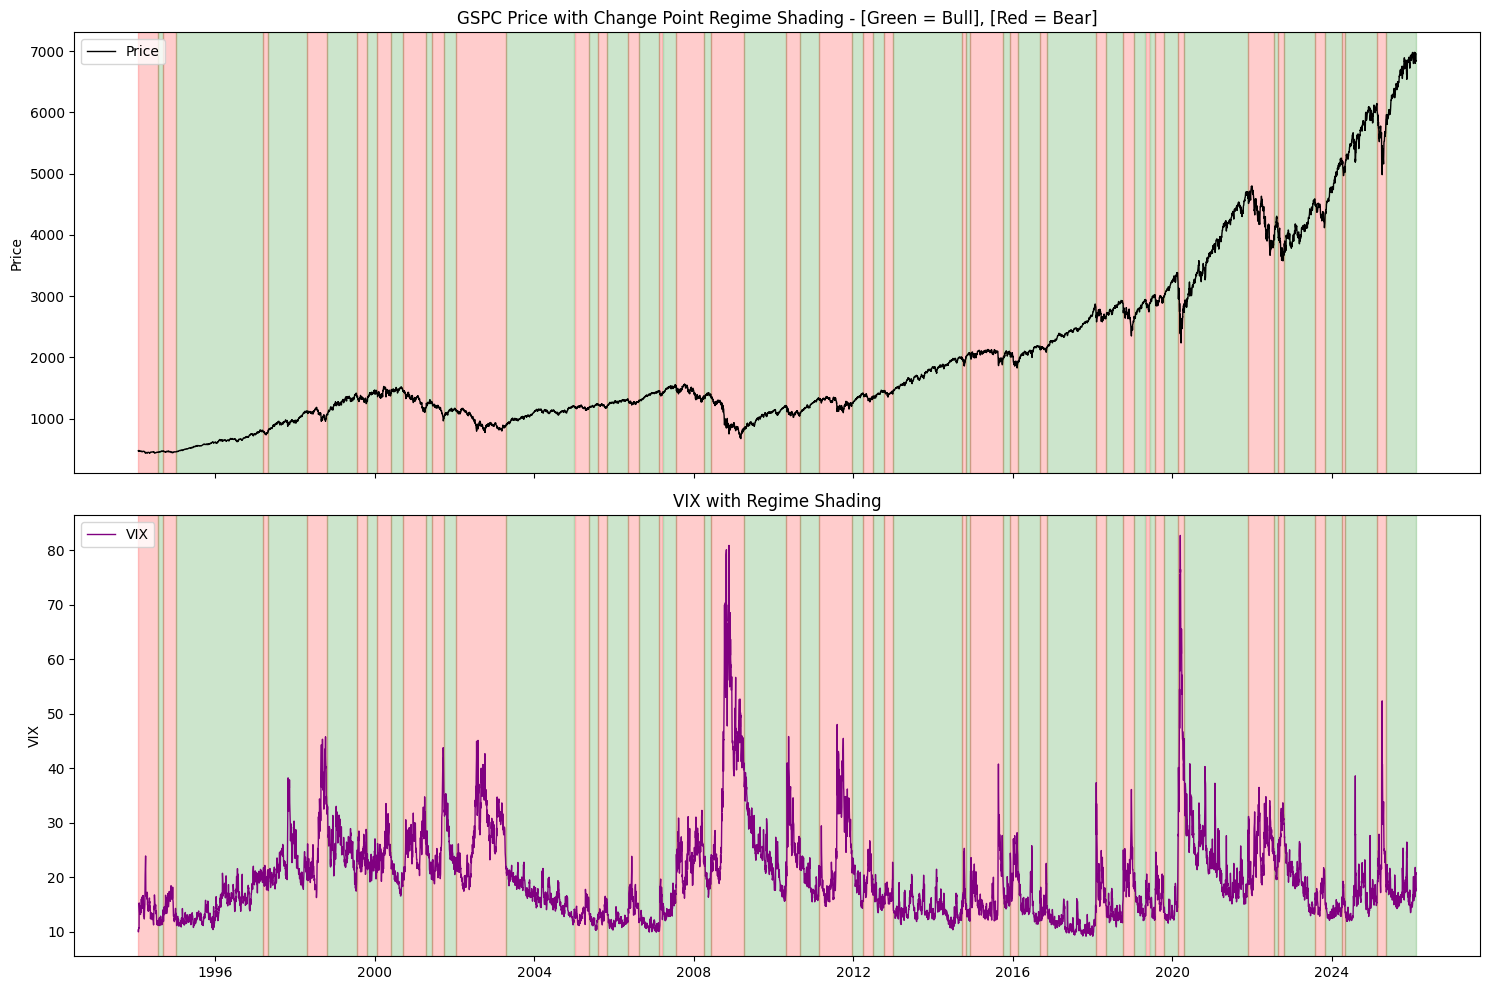

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.set_title(f'{price_col} Price with Change Point Regime Shading - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Add shading
df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

# Plot 2: VIX with regime shading
ax2.plot(df['Date'], df['VIX'], color='purple', linewidth=1, label='VIX')
ax2.set_title('VIX with Regime Shading')
ax2.set_ylabel('VIX')
ax2.legend(loc='upper left')

for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax2.axvspan(start_date, end_date, color=color, alpha=0.2)

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [14]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

output_csv = r'C:\Users\jacob\Documents\GitHub\COMP0047-Data-Science-Project\notebooks\data\multivariate_changepoint_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")

Validation passed: No missing values in 'regime' column.
Dataset saved to C:\Users\jacob\Documents\GitHub\COMP0047-Data-Science-Project\notebooks\data\multivariate_changepoint_labeled_dataset.csv
